## Problem 1

#### Numerical simulation

In [1]:
import numpy as np

class ItoSim():
    """Simulate given Ito process"""

    def __init__(self, h: float, rng: np.random.Generator) -> None:
        self.h = h


    def next_step(self, x: np.ndarray, eps: np.ndarray):
        """One discrete step of process"""
        return x * (1 - self.h) + np.sqrt(2 * self.h) * eps

    def simulate(self, x0: np.ndarray, num_steps: int) -> np.ndarray:

        trajectories: np.ndarray = np.zeros((num_steps, x0.size))
        trajectories[0] = x0

        for i in range(num_steps - 1):
            eps = rng.normal(size=x0.shape)
            trajectories[i + 1] = self.next_step(trajectories[i], eps)

        return trajectories

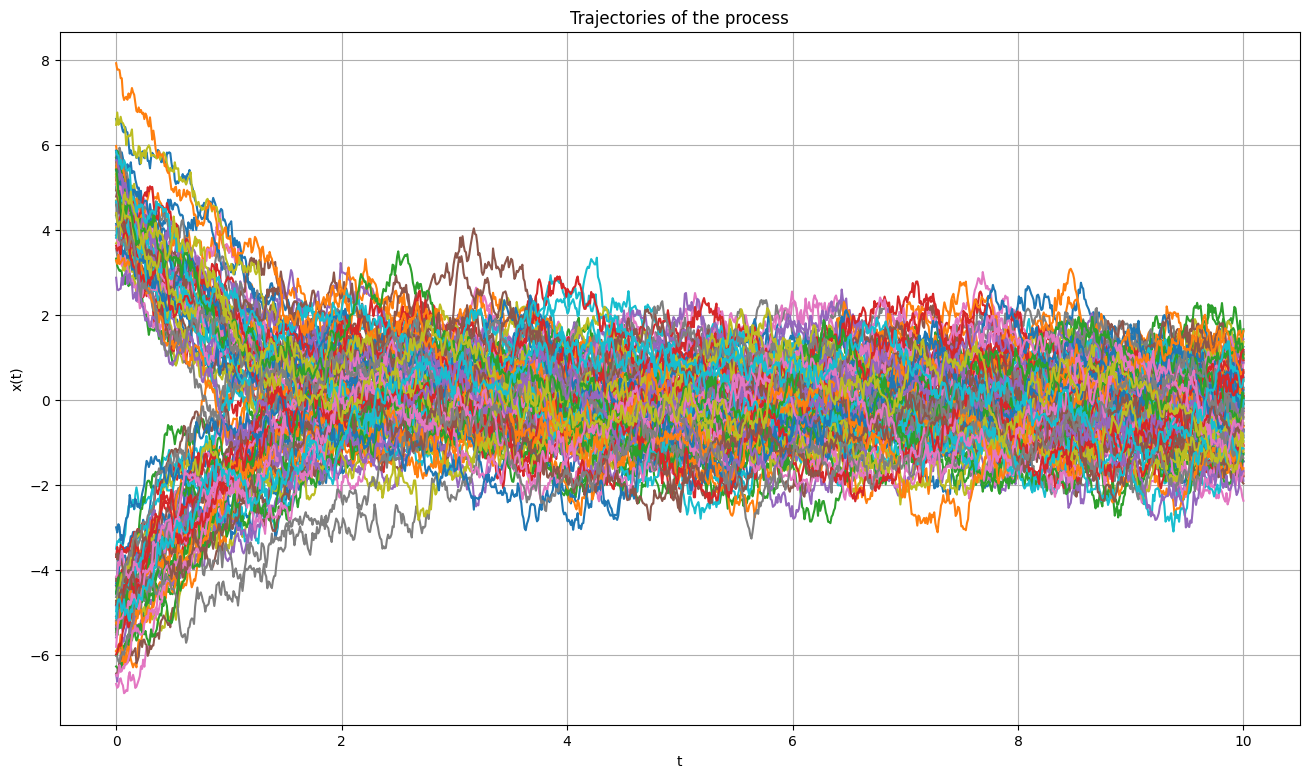

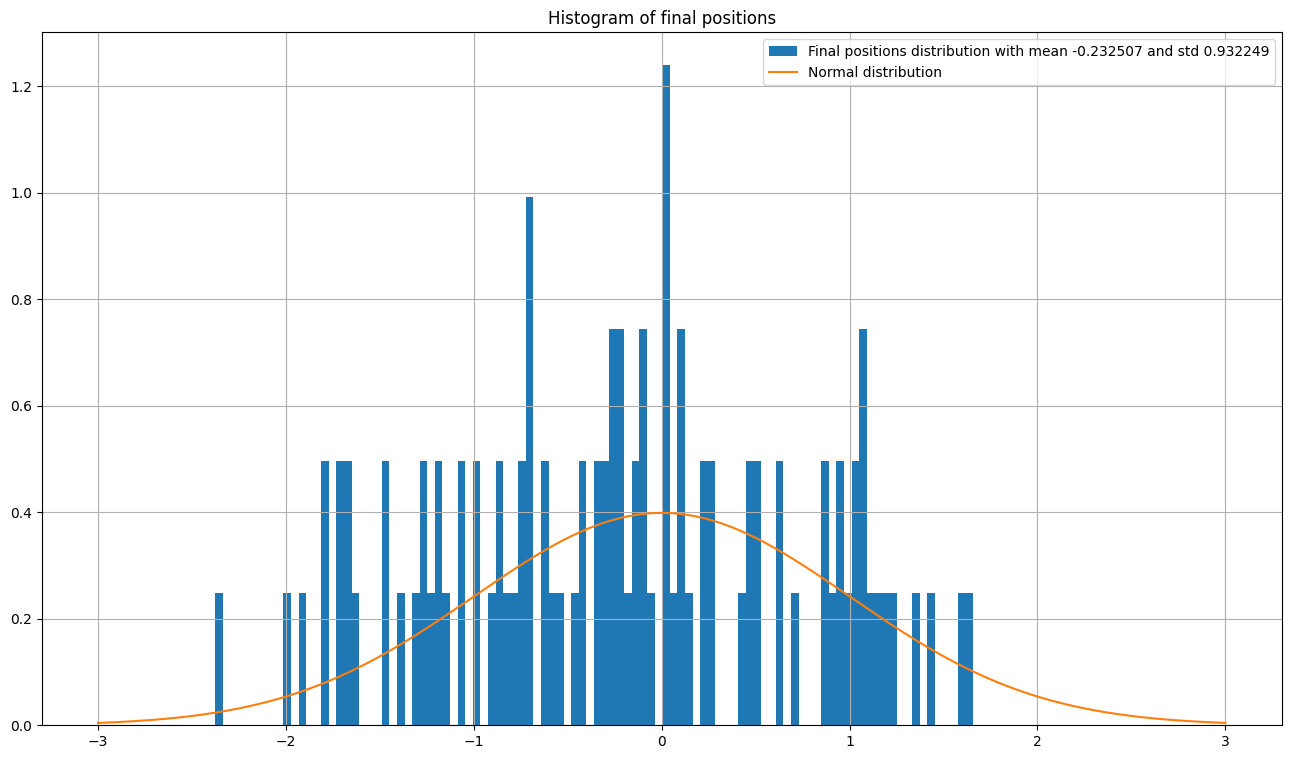

In [54]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
num_steps = 1000
h = 0.01

def compute_and_plot_trajectories(rng: np.random.Generator, x0_size: int, num_steps: int, h: float):
    components = rng.choice([-5, +5], size=x0_size)
    x0 = components + rng.normal(0, 1, size=x0_size)

    x_plot = np.linspace(0, num_steps * h, num_steps)

    sim = ItoSim(h=h, rng=rng)
    trajectories = sim.simulate(x0, num_steps)

    plt.figure(figsize=(16, 9))

    for i in range(trajectories.shape[1]):
        plt.plot(x_plot, trajectories[:, i])

    plt.title("Trajectories of the process")
    plt.xlabel("t")
    plt.ylabel("x(t)")
    plt.grid()
    plt.show()


    plt.figure(figsize=(16, 9))

    x_normal = np.linspace(-3, 3, 1000)
    plt.hist(trajectories[-1], density=True, bins=100, label="Final positions distribution with mean %f and std %f" % (trajectories[-1].mean(), trajectories[-1].std()))
    plt.plot(x_normal, 1 / np.sqrt(2 * np.pi) * np.exp(-x_normal**2 / 2), label="Normal distribution")
    plt.title("Histogram of final positions")
    plt.grid()
    plt.legend()
    plt.show()

    return x0, trajectories

x0_100, trajectories_100 = compute_and_plot_trajectories(rng, 100, num_steps, h)

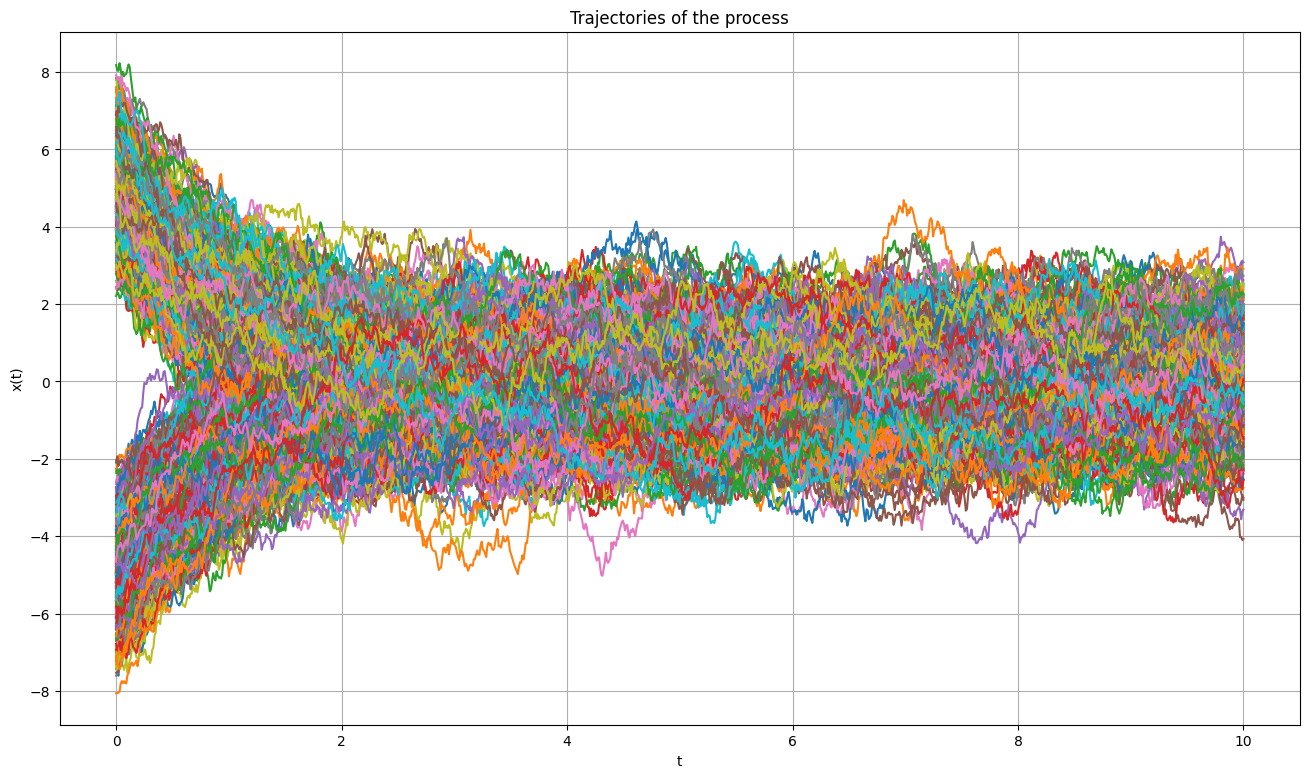

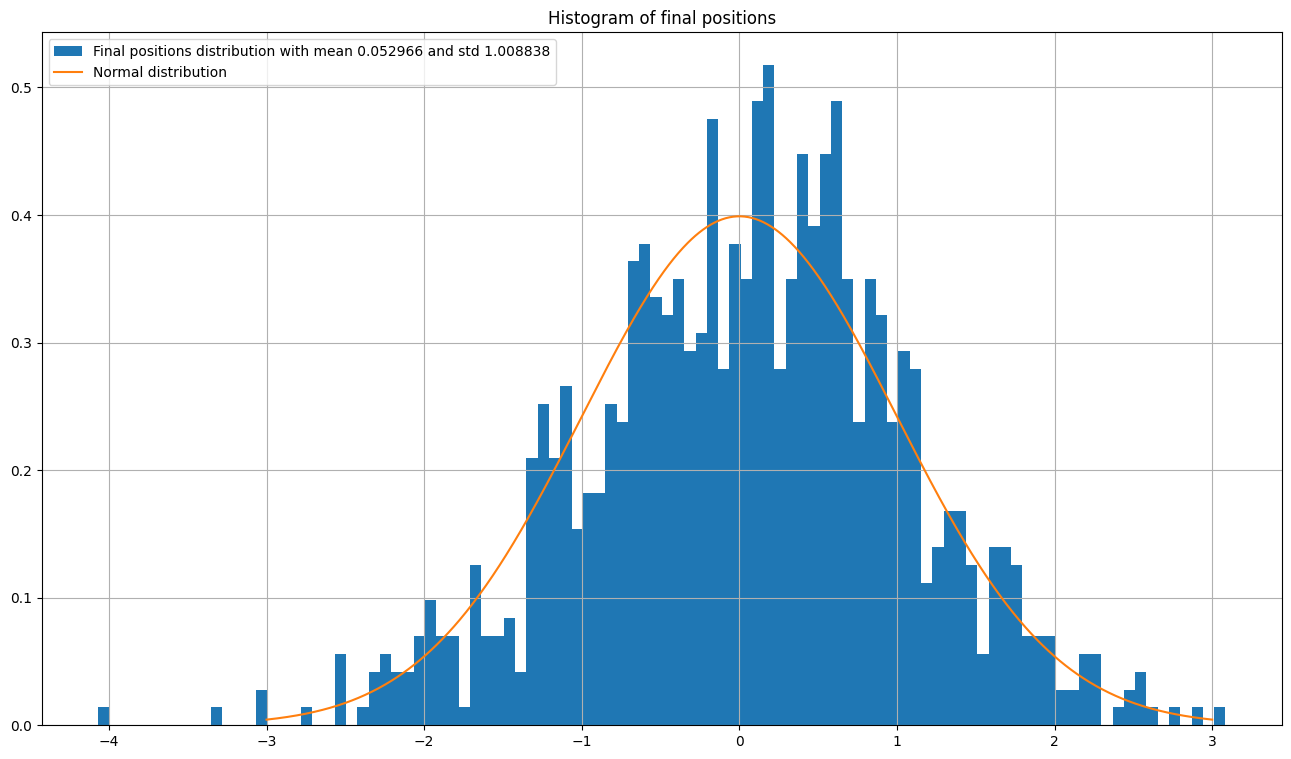

In [55]:
#As we get not enough "normality", lets try to increase the number of initial dots

#Now its much more closer to N(0,1)
x0_1000, trajectories_1000 = compute_and_plot_trajectories(rng, 1000, num_steps, h)

#### Analytical $p(x,t)$

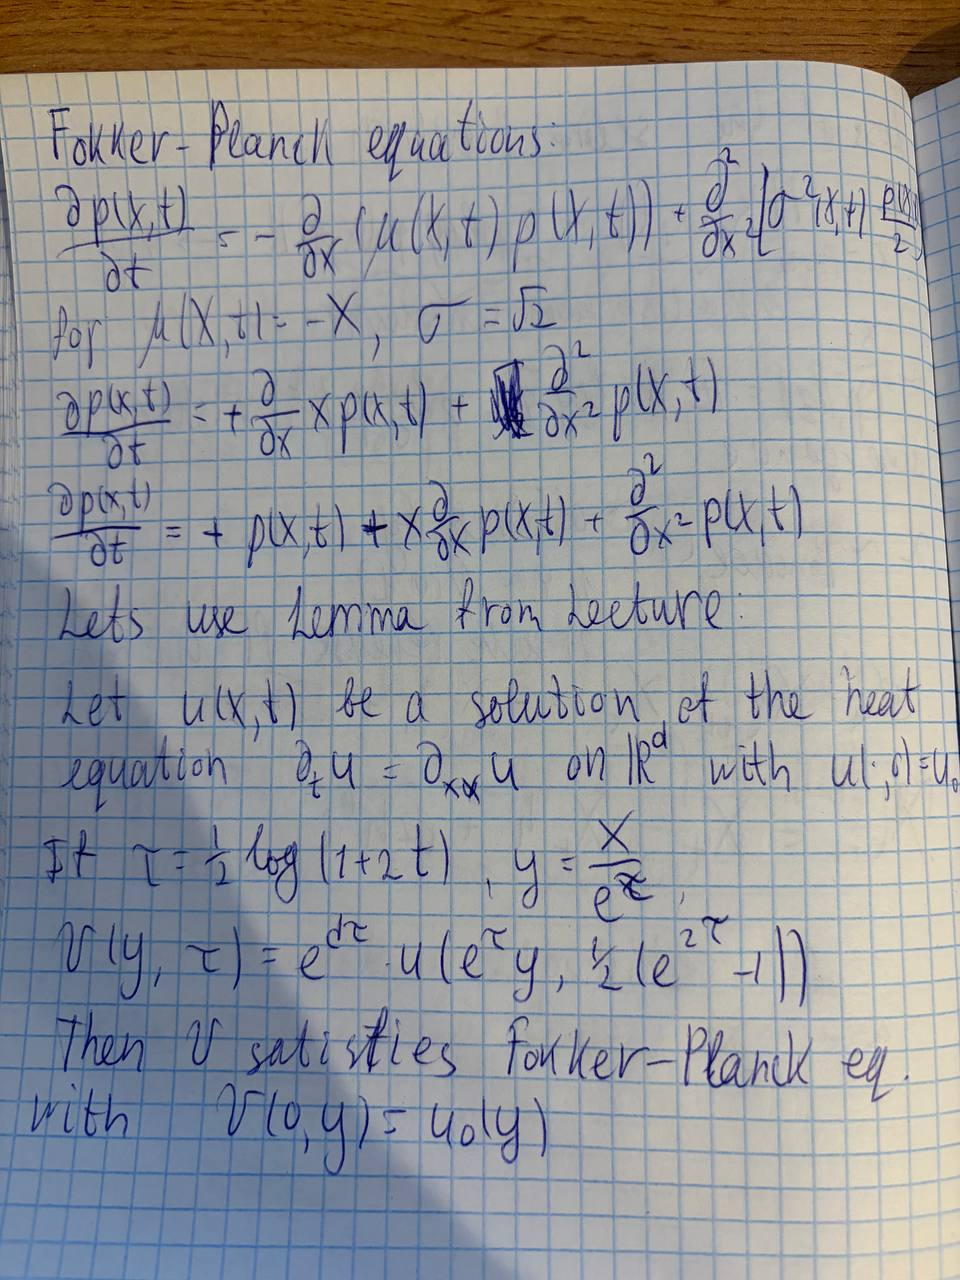

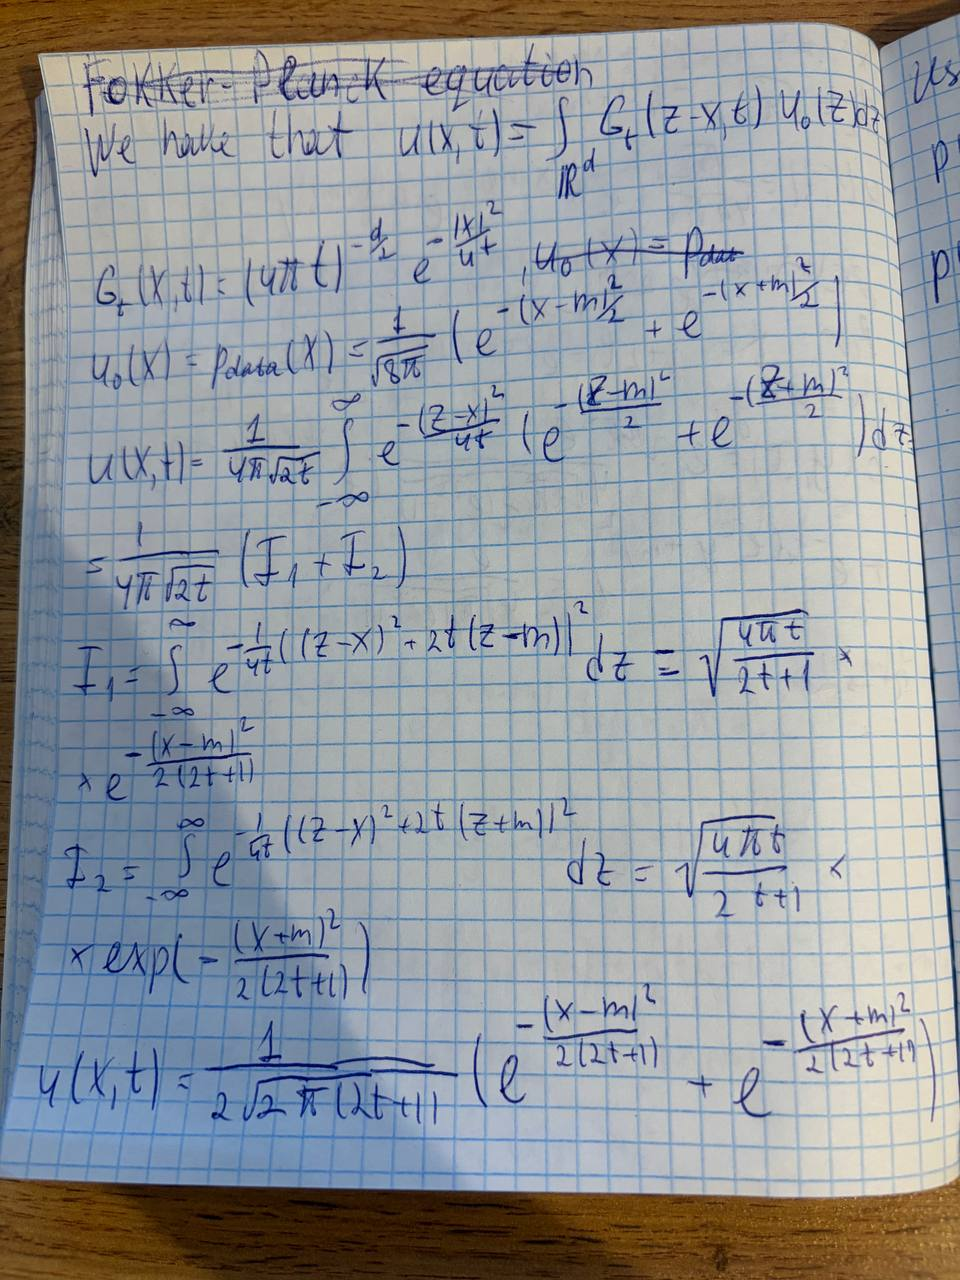

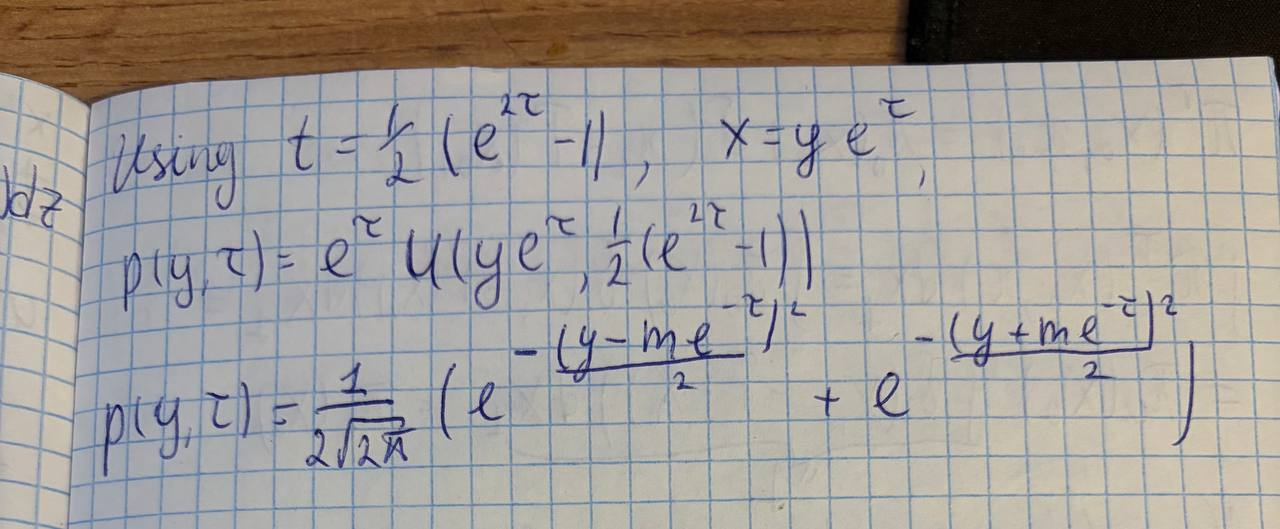

/tmp/ipykernel_36192/3086431883.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


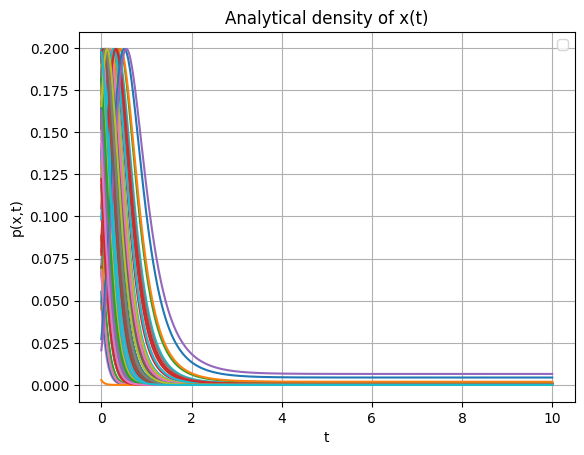

In [49]:
def analytical_p(y: np.ndarray, tau: np.ndarray, mean: float):

    coeff: float = 1/ np.sqrt(8 * np.pi)

    first_exp = np.exp( - (y - mean * np.exp(-tau)) * (y - mean * np.exp(-tau)) / 2)

    #print(first_exp)

    second_exp = np.exp( - (y + mean * np.exp(-tau)) * (y + mean * np.exp(-tau)) / 2)

    #print(second_exp)

    return coeff * (first_exp + second_exp)


#constructiong the grid of density for heat map
timesteps = np.linspace(0, num_steps * h, num_steps)
x_grid = np.linspace(x0_100.min(), x0_100.max(), 100)

density = np.zeros((num_steps, x_grid.size))

for i, t in enumerate(timesteps):
    density[i] = analytical_p(x_grid, t, 5)

#Lets plot the density on trajectories
for i, x in enumerate(x0_100):
    plt.plot(timesteps, analytical_p(x, timesteps, 5))


plt.grid()
plt.legend()
plt.title("Analytical density of x(t)")
plt.xlabel("t")
plt.ylabel("p(x,t)")
plt.show()



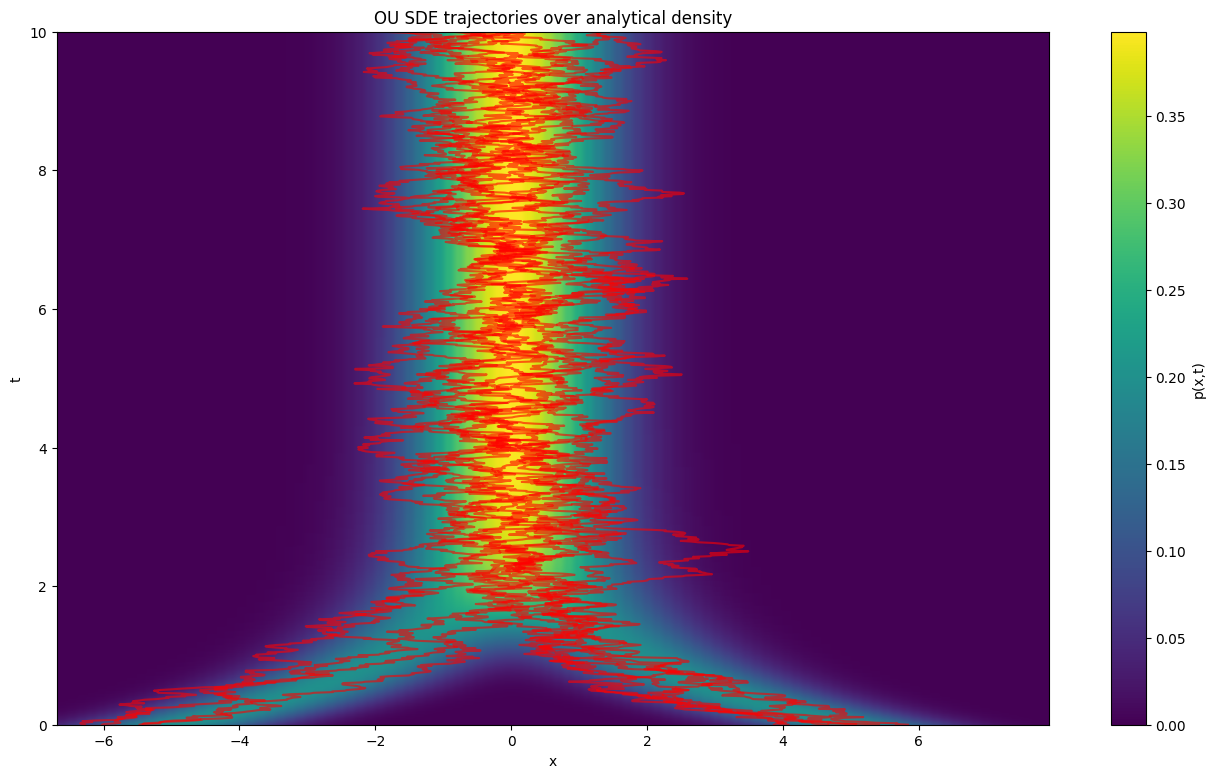

In [50]:
plt.figure(figsize=(16,9))

plt.imshow(
    density,
    extent=[x_grid.min(), x_grid.max(), timesteps.max(), timesteps.min()],
    aspect='auto',
    cmap='viridis'
)

idx = rng.choice(trajectories_100.shape[1], size=10, replace=False)

for j in idx:
    plt.plot(trajectories_100[:, j], timesteps, color='red', alpha=0.6)

plt.gca().invert_yaxis()
plt.xlabel("x")
plt.ylabel("t")
plt.title("OU SDE trajectories over analytical density")
plt.colorbar(label="p(x,t)")
plt.show()

####  The probability flow ODE

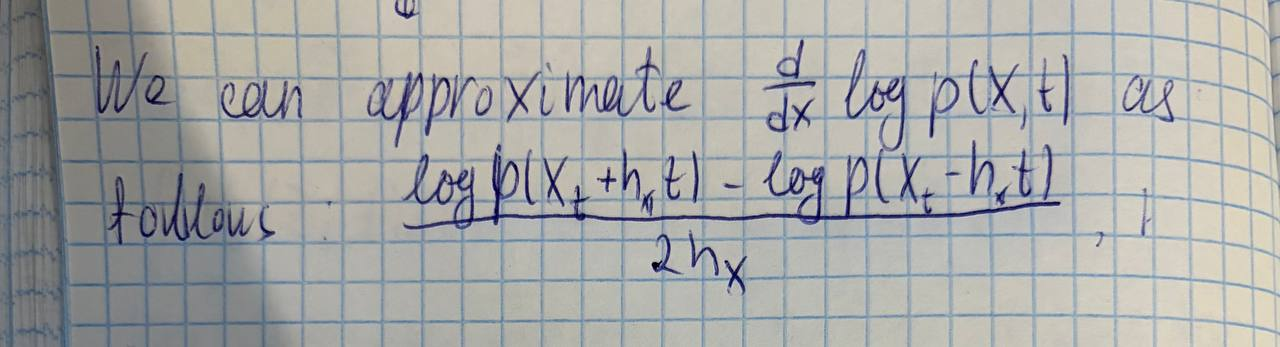

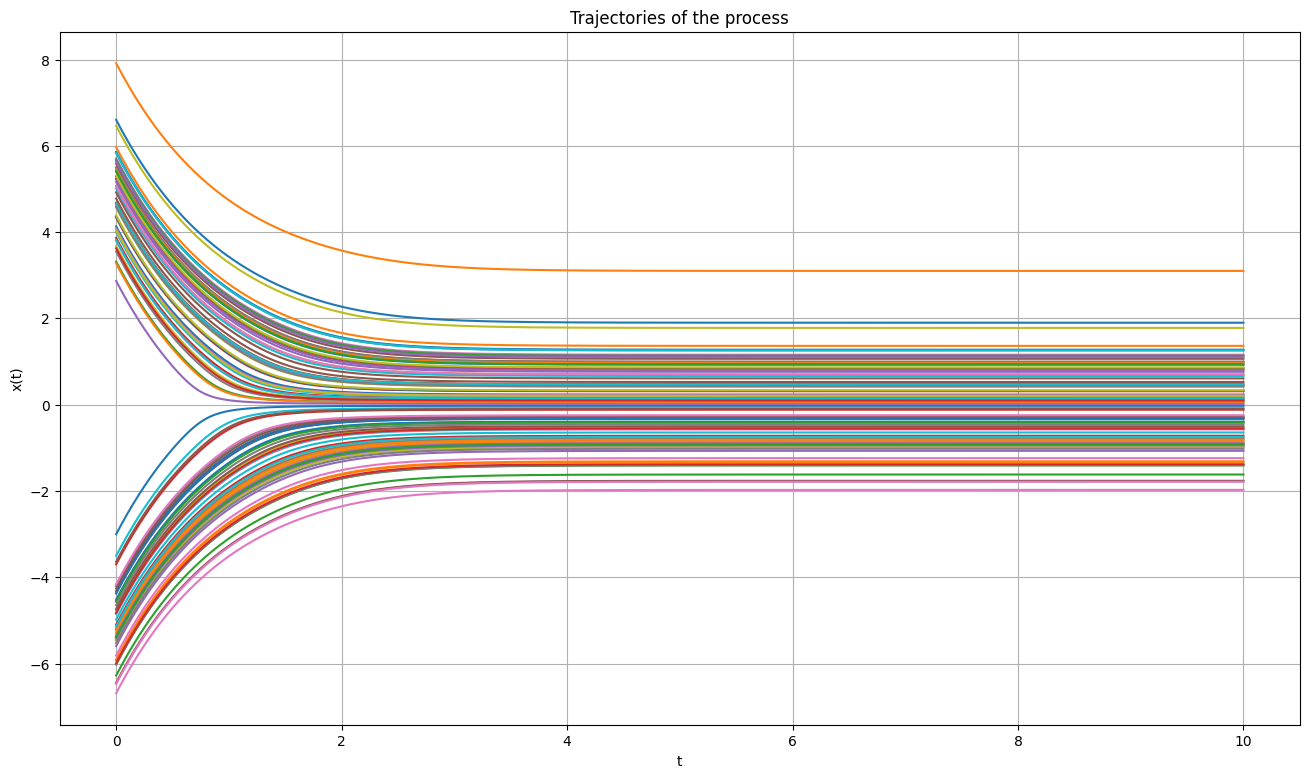

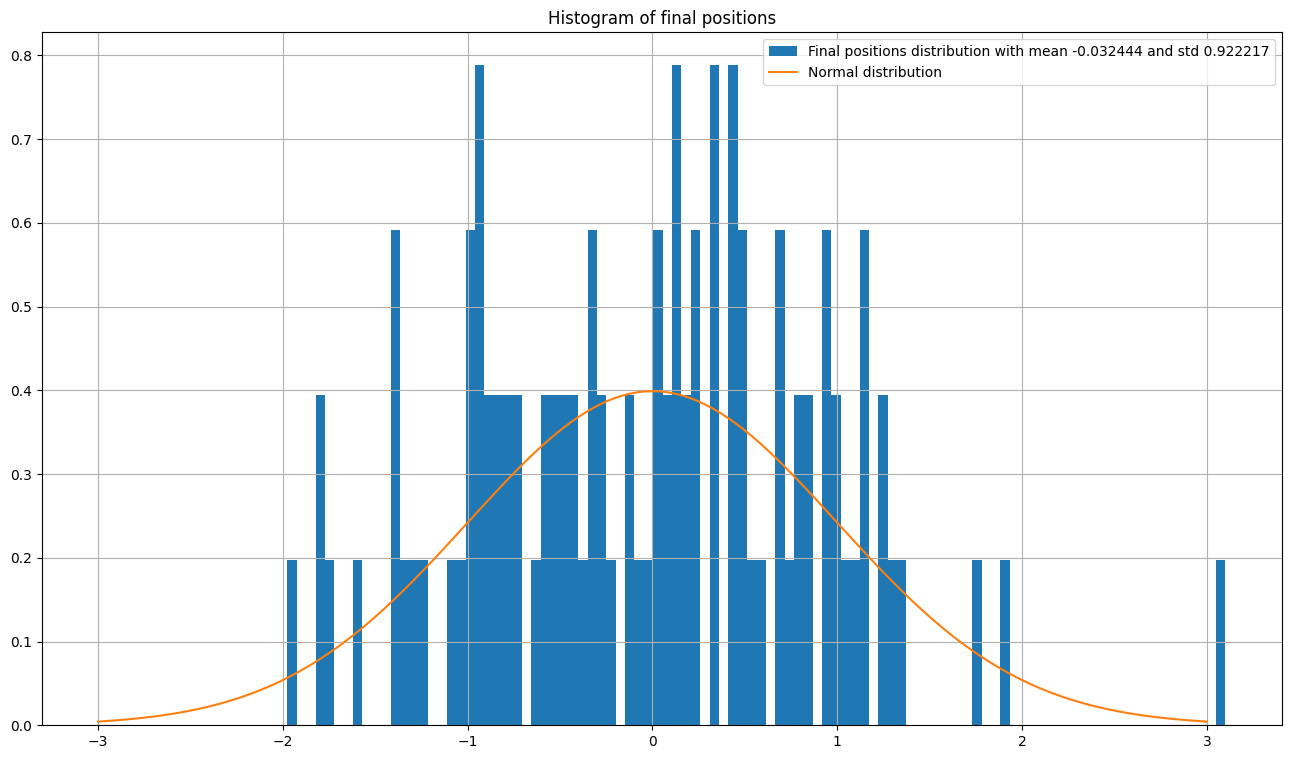

In [57]:
class ProbabilityFlowODE():
    def __init__(self, h_t: float, h_x: float, rng: np.random.Generator) -> None:
        self.h_t = h_t
        self.h_x = h_x
        self.rng = rng

    def next_step(self, x: np.ndarray, t: float):
        return x * (1 - self.h_t)  - self.h_t * (np.log(analytical_p(x + self.h_x, t, 5)) - np.log(analytical_p(x - self.h_x, t, 5))) / (2 * self.h_x)

    def simulate(self, x0: np.ndarray, num_steps: int):
        trajectories = np.zeros((num_steps, x0.size))
        trajectories[0] = x0

        for i in range(num_steps - 1):
            trajectories[i + 1] = self.next_step(trajectories[i], i * self.h_t)

        return trajectories


x_plot = np.linspace(0, num_steps * h, num_steps)
h_x = 0.001

sim = ProbabilityFlowODE(h_t=h, h_x=h_x, rng=rng)
trajectories = sim.simulate(x0_100, num_steps)

plt.figure(figsize=(16, 9))

for i in range(trajectories.shape[1]):
    plt.plot(x_plot, trajectories[:, i])

plt.title("Trajectories of the process")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid()
plt.show()


plt.figure(figsize=(16, 9))

x_normal = np.linspace(-3, 3, 1000)
plt.hist(trajectories[-1], density=True, bins=100, label="Final positions distribution with mean %f and std %f" % (trajectories[-1].mean(), trajectories[-1].std()))
plt.plot(x_normal, 1 / np.sqrt(2 * np.pi) * np.exp(-x_normal**2 / 2), label="Normal distribution")
plt.title("Histogram of final positions")
plt.grid()
plt.legend()
plt.show()





## Problem 2

#### Part 1

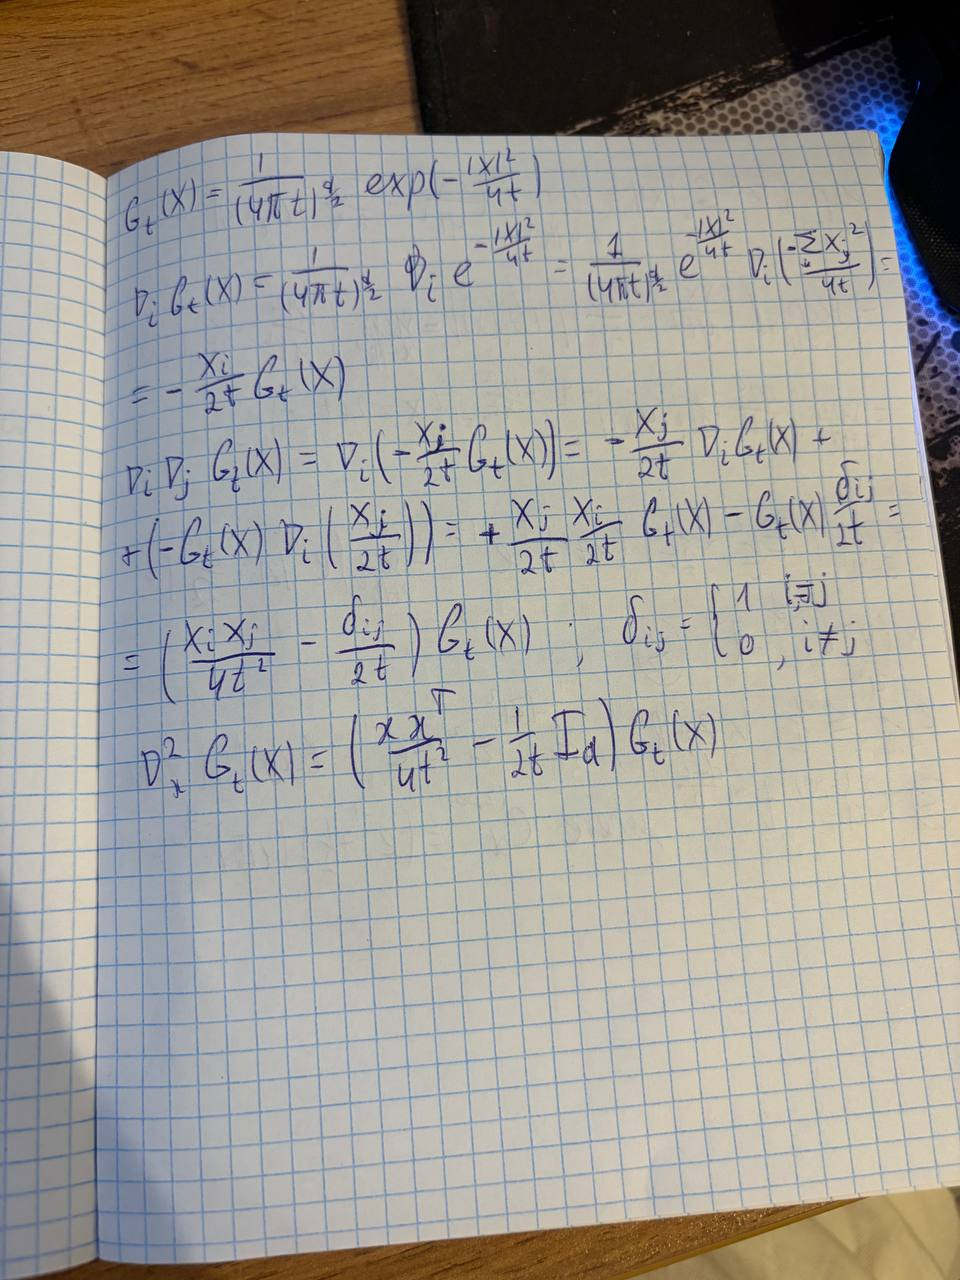

#### Part 2

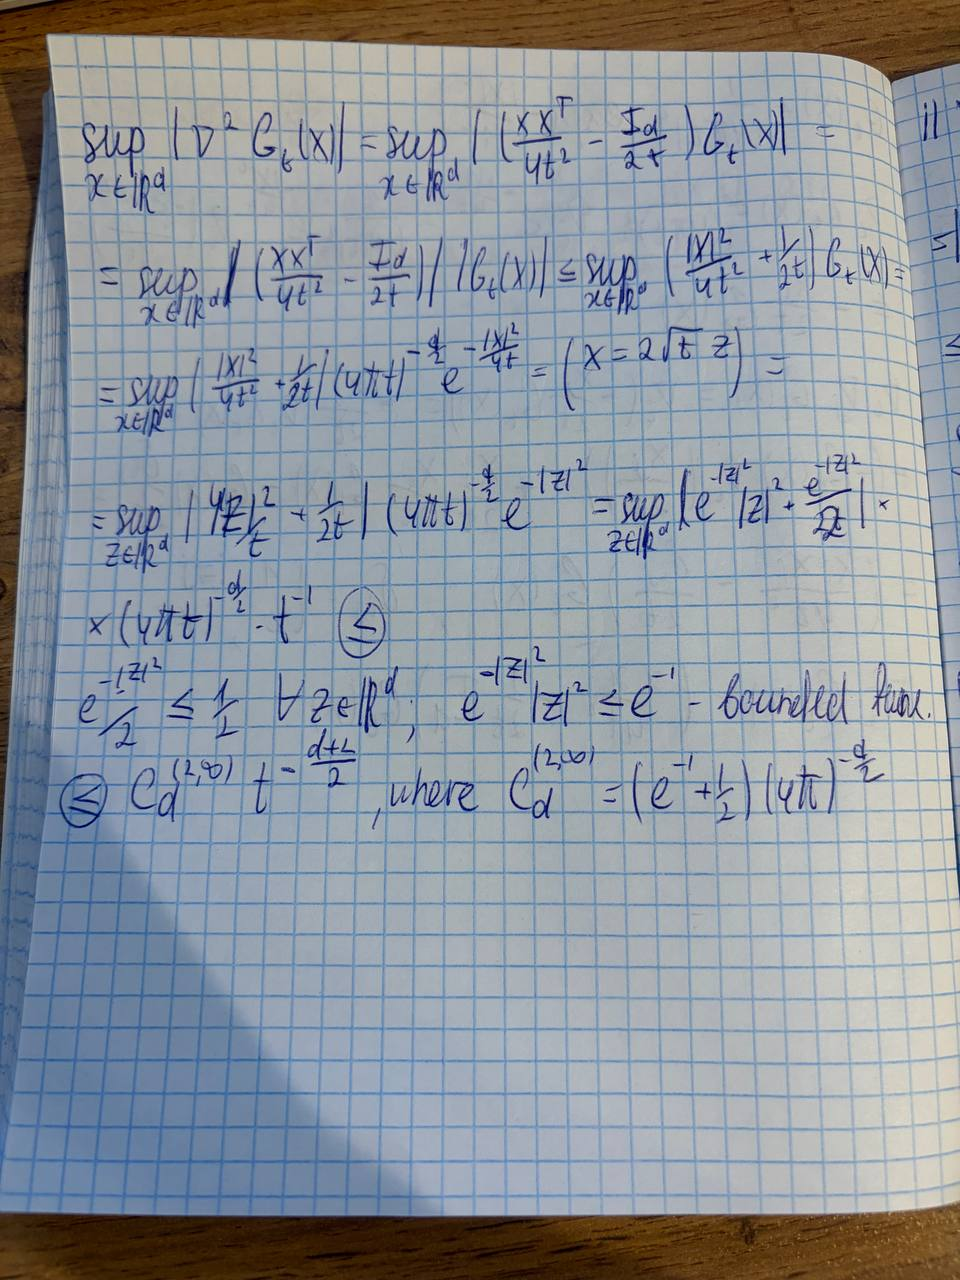

#### Part 3

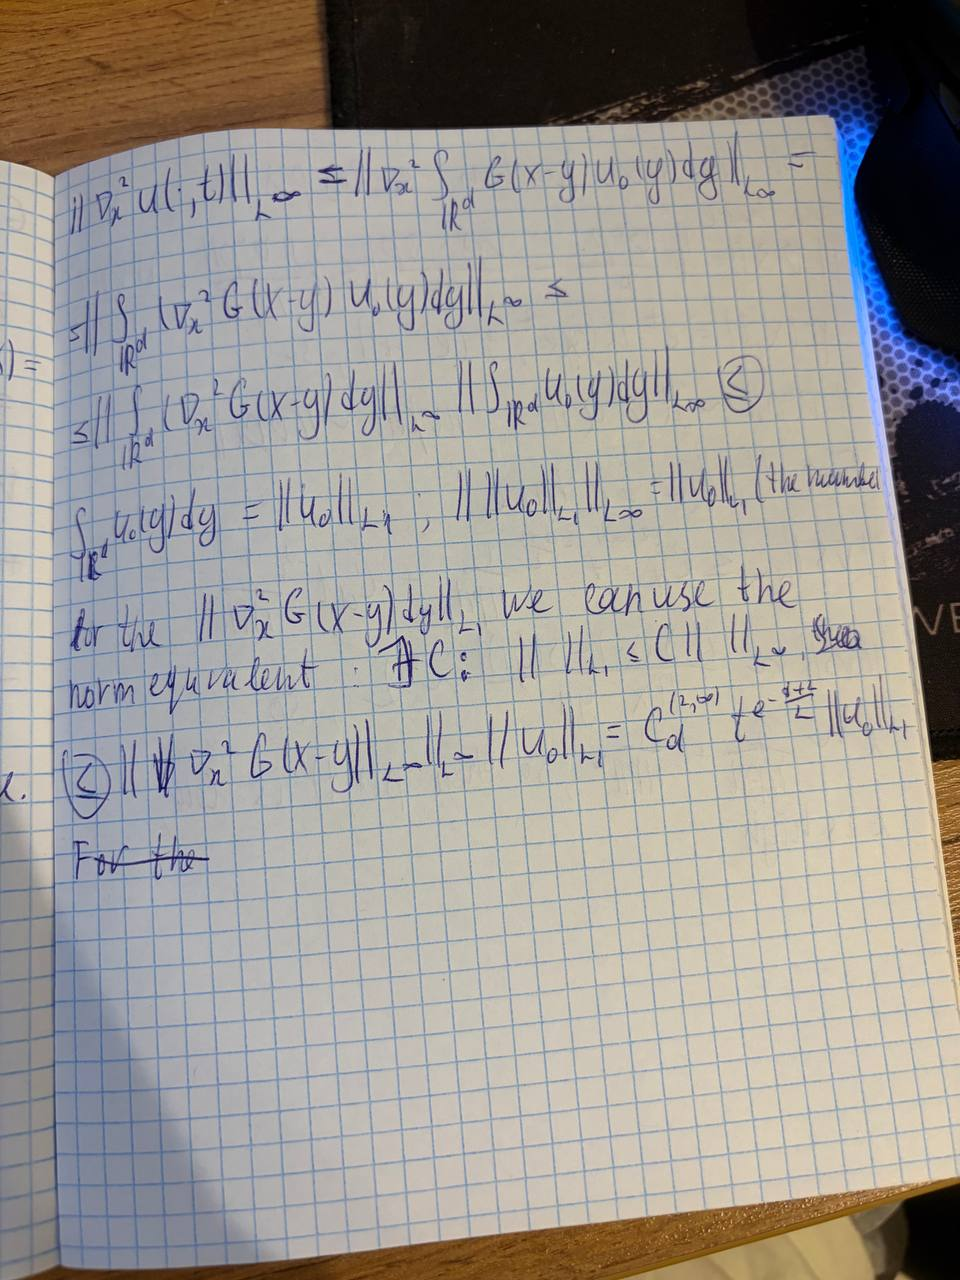

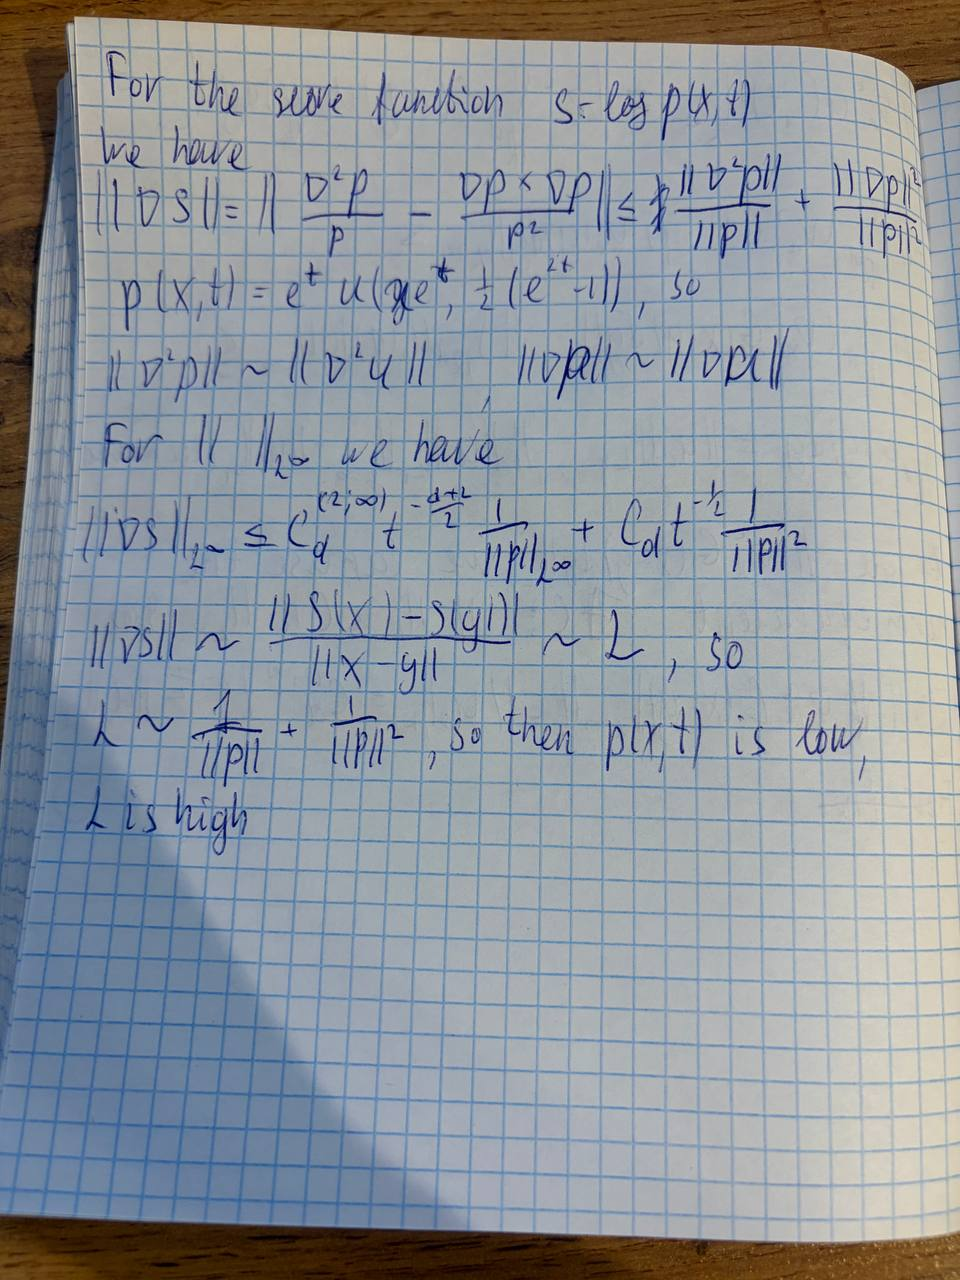

## Problem 3

#### Part 1

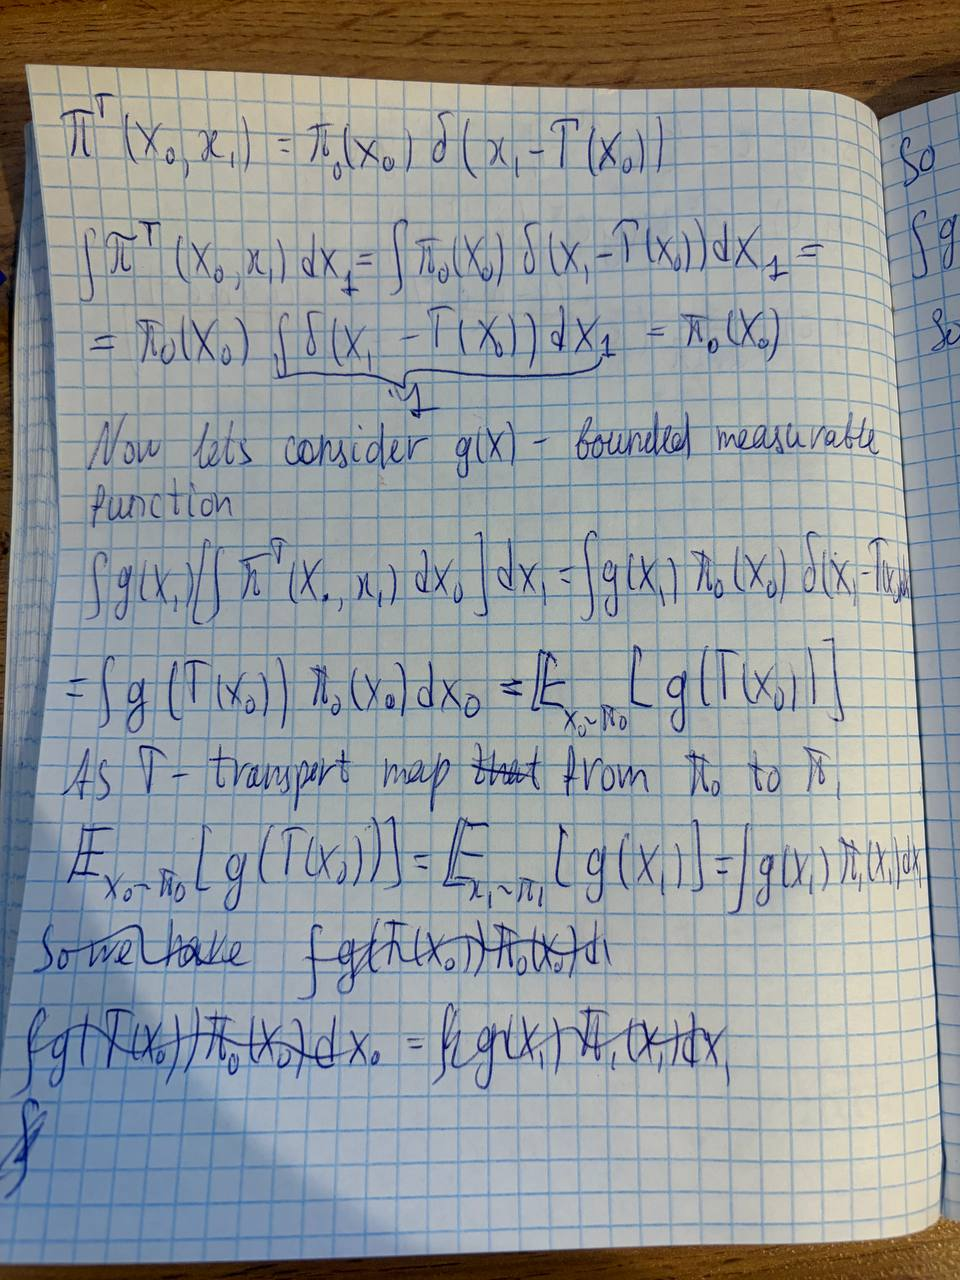

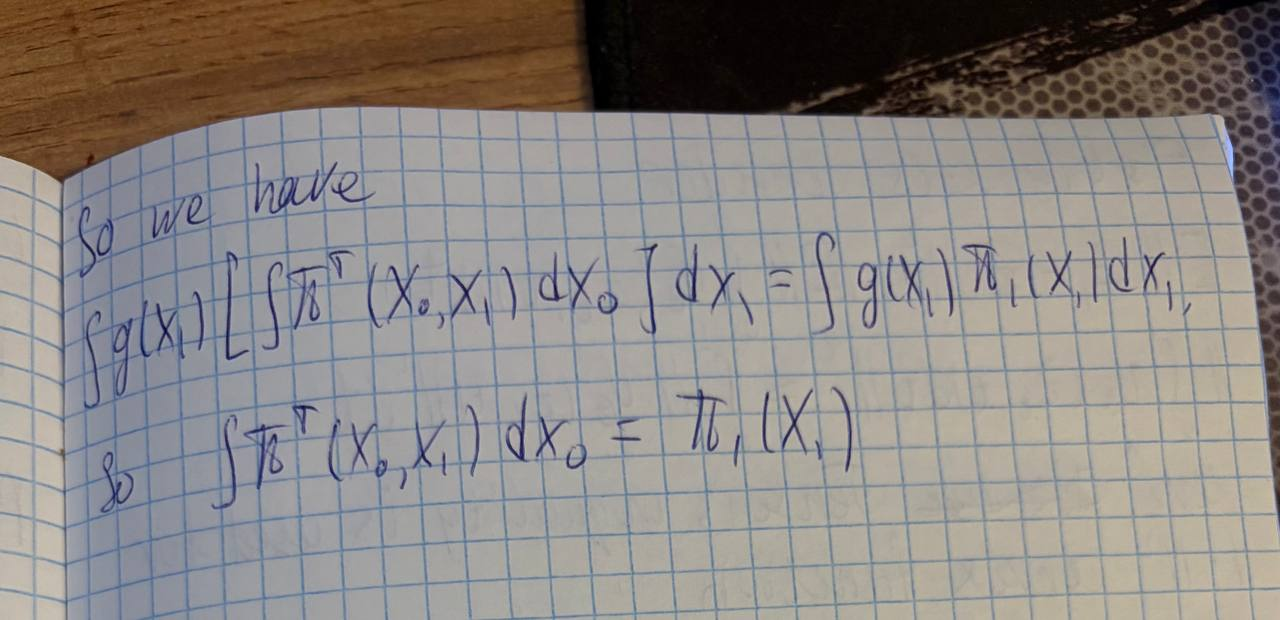

#### Part 2

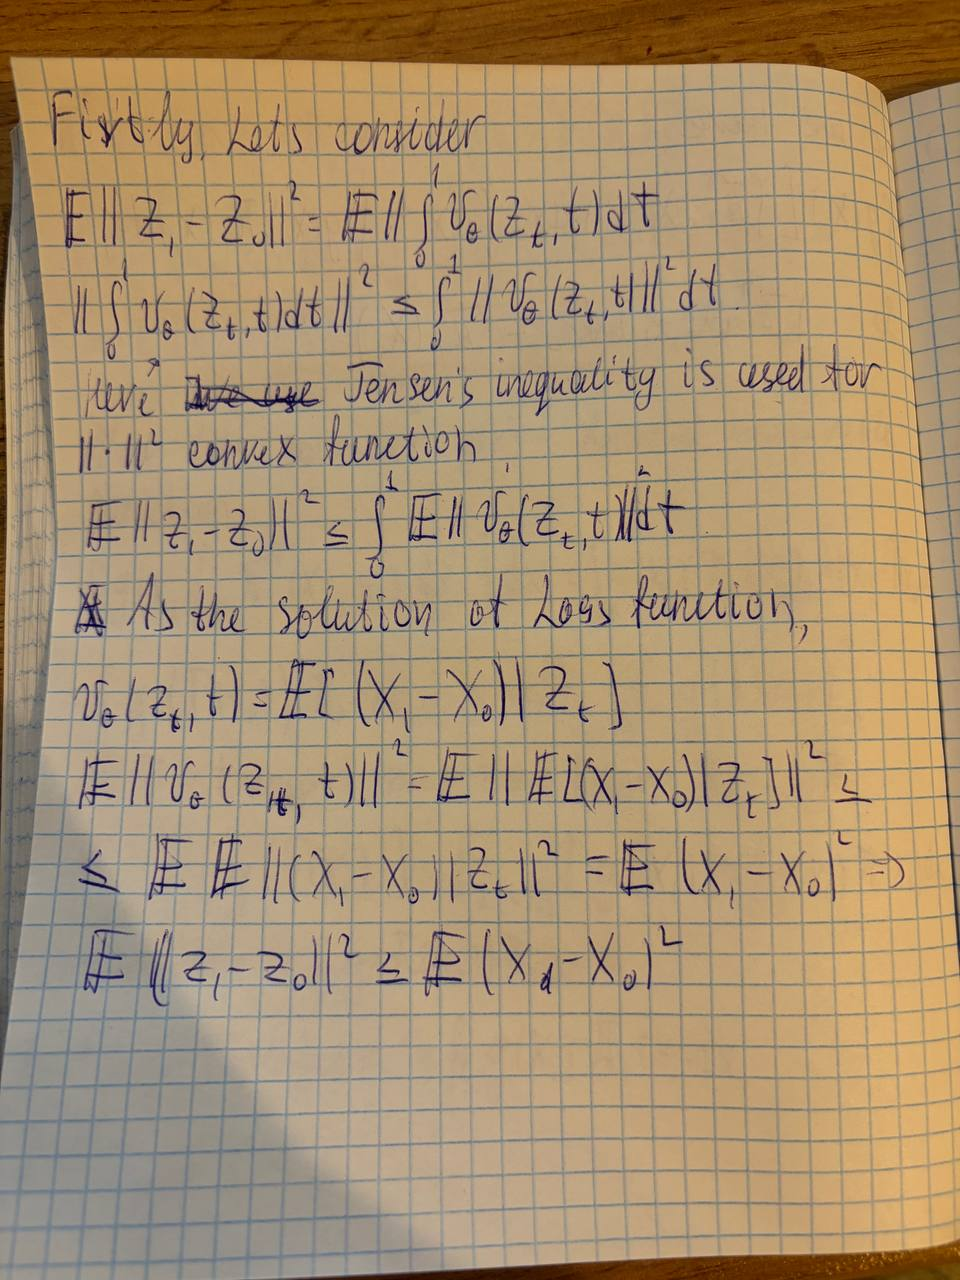

#### Part 3

In [62]:
# make samples

import torch
import numpy as np
import torch.nn as nn
from torch.distributions import Normal, Categorical
from torch.distributions.multivariate_normal import MultivariateNormal
from torch.distributions.mixture_same_family import MixtureSameFamily
import matplotlib.pyplot as plt
import torch.nn.functional as F

D = 10.
M = D+5
VAR = 0.3
DOT_SIZE = 4
COMP = 3

initial_mix = Categorical(torch.tensor([1/COMP for i in range(COMP)]))
initial_comp = MultivariateNormal(torch.tensor([[D * np.sqrt(3) / 2., D / 2.], [-D * np.sqrt(3) / 2., D / 2.], [0.0, - D * np.sqrt(3) / 2.]]).float(), VAR * torch.stack([torch.eye(2) for i in range(COMP)]))
initial_model = MixtureSameFamily(initial_mix, initial_comp)
samples_0 = initial_model.sample([10000])

target_mix = Categorical(torch.tensor([1/COMP for i in range(COMP)]))
target_comp = MultivariateNormal(torch.tensor([[D * np.sqrt(3) / 2., - D / 2.], [-D * np.sqrt(3) / 2., - D / 2.], [0.0, D * np.sqrt(3) / 2.]]).float(), VAR * torch.stack([torch.eye(2) for i in range(COMP)]))
target_model = MixtureSameFamily(target_mix, target_comp)
samples_1 = target_model.sample([10000])
print('Shape of the samples:', samples_0.shape, samples_1.shape)

Shape of the samples: torch.Size([10000, 2]) torch.Size([10000, 2])


In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim=2, hidden_num=100):
        super().__init__()
        self.fc1 = nn.Linear(input_dim+1, hidden_num, bias=True)
        self.fc2 = nn.Linear(hidden_num, hidden_num, bias=True)
        self.fc3 = nn.Linear(hidden_num, input_dim, bias=True)
        self.act = lambda x: torch.tanh(x)

    def forward(self, x_input, t):
        inputs = torch.cat([x_input, t], dim=1)
        x = self.fc1(inputs)
        x = self.act(x)
        x = self.fc2(x)
        x = self.act(x)
        x = self.fc3(x)

        return x

class RectifiedFlow():
  def __init__(self, model=None, num_steps=1000):
    self.model = model
    self.N = num_steps

  def get_train_tuple(self, z0=None, z1=None):
    t = torch.rand((z1.shape[0], 1))
    z_t =  t * z1 + (1.-t) * z0
    target = z1 - z0

    return z_t, t, target

  @torch.no_grad()
  def sample_ode(self, z0=None, N=None):
    ### NOTE: Use Euler method to sample from the learned flow
    if N is None:
      N = self.N
    dt = 1./N
    traj = [] # to store the trajectory
    z = z0.detach().clone()
    batchsize = z.shape[0]

    traj.append(z.detach().clone())
    for i in range(N):
      t = torch.ones((batchsize,1)) * i / N
      pred = self.model(z, t)
      z = z.detach().clone() + pred * dt

      traj.append(z.detach().clone())

    return traj

def train_rectified_flow(rectified_flow, optimizer, pairs, batchsize, inner_iters):
  loss_curve = []
  for i in range(inner_iters+1):
    optimizer.zero_grad()
    indices = torch.randperm(len(pairs))[:batchsize]
    batch = pairs[indices]
    z0 = batch[:, 0].detach().clone()
    z1 = batch[:, 1].detach().clone()
    z_t, t, target = rectified_flow.get_train_tuple(z0=z0, z1=z1)

    pred = rectified_flow.model(z_t, t)
    loss = (target - pred).view(pred.shape[0], -1).abs().pow(2).sum(dim=1)
    loss = loss.mean()
    loss.backward()

    optimizer.step()
    loss_curve.append(np.log(loss.item())) ## to store the loss curve

  return rectified_flow, loss_curve

@torch.no_grad()
def draw_plot(rectified_flow, z0, z1, N=None):
  traj = rectified_flow.sample_ode(z0=z0, N=N)

  plt.figure(figsize=(4,4))
  plt.xlim(-M,M)
  plt.ylim(-M,M)

  plt.scatter(z1[:, 0].cpu().numpy(), z1[:, 1].cpu().numpy(), label=r'$\pi_1$', alpha=0.15)
  plt.scatter(traj[0][:, 0].cpu().numpy(), traj[0][:, 1].cpu().numpy(), label=r'$\pi_0$', alpha=0.15)
  plt.scatter(traj[-1][:, 0].cpu().numpy(), traj[-1][:, 1].cpu().numpy(), label='Generated', alpha=0.15)
  plt.legend()
  plt.title('Distribution')
  plt.tight_layout()

  traj_particles = torch.stack(traj)
  plt.figure(figsize=(4,4))
  plt.xlim(-M,M)
  plt.ylim(-M,M)
  plt.axis('equal')
  for i in range(30):
    plt.plot(traj_particles[:, i, 0], traj_particles[:, i, 1])
  plt.title('Transport Trajectory')
  plt.tight_layout()

Text(0.5, 1.0, 'Training Loss Curve')

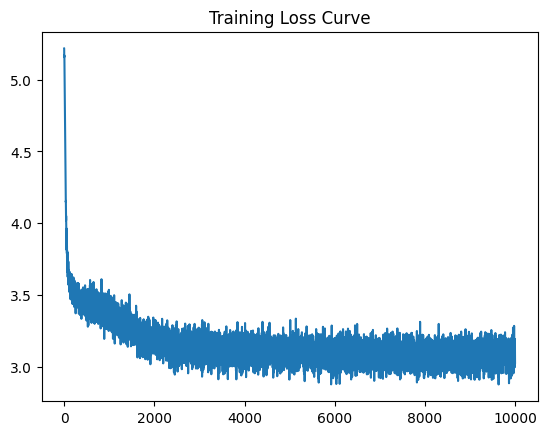

In [64]:
#1-rectified flow

x_0 = samples_0.detach().clone()[torch.randperm(len(samples_0))]
x_1 = samples_1.detach().clone()[torch.randperm(len(samples_1))]
x_pairs = torch.stack([x_0, x_1], dim=1)

iterations = 10000
batchsize = 2048
input_dim = 2

rectified_flow_1 = RectifiedFlow(model=MLP(input_dim, hidden_num=100), num_steps=100)
optimizer = torch.optim.Adam(rectified_flow_1.model.parameters(), lr=5e-3)

rectified_flow_1, loss_curve = train_rectified_flow(rectified_flow_1, optimizer, x_pairs, batchsize, iterations)
plt.plot(np.linspace(0, iterations, iterations+1), loss_curve[:(iterations+1)])
plt.title('Training Loss Curve')


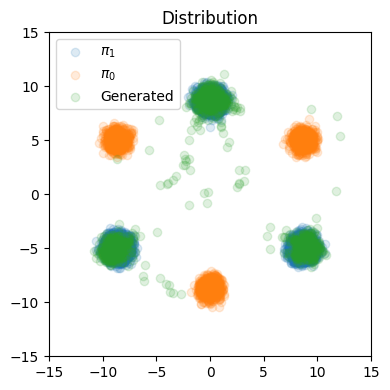

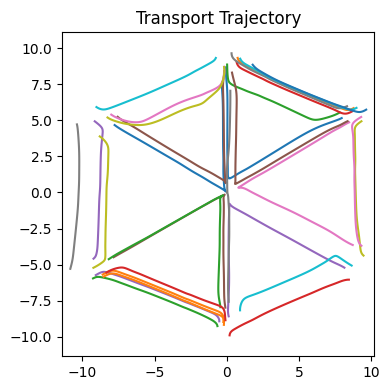

In [65]:
draw_plot(rectified_flow_1, z0=initial_model.sample([2000]), z1=samples_1.detach().clone(), N=100)

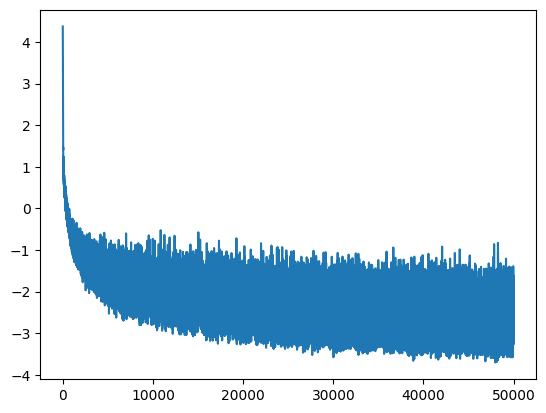

In [66]:
#2-rectified flow
z10 = samples_0.detach().clone()
traj = rectified_flow_1.sample_ode(z0=z10.detach().clone(), N=100)
z11 = traj[-1].detach().clone()
z_pairs = torch.stack([z10, z11], dim=1)


reflow_iterations = 50000

rectified_flow_2 = RectifiedFlow(model=MLP(input_dim, hidden_num=100), num_steps=100)
import copy
rectified_flow_2.net = copy.deepcopy(rectified_flow_1) # we fine-tune the model from 1-Rectified Flow for faster training.
optimizer = torch.optim.Adam(rectified_flow_2.model.parameters(), lr=5e-3)

rectified_flow_2, loss_curve = train_rectified_flow(rectified_flow_2, optimizer, z_pairs, batchsize, reflow_iterations)
plt.plot(np.linspace(0, reflow_iterations, reflow_iterations+1), loss_curve[:(reflow_iterations+1)])

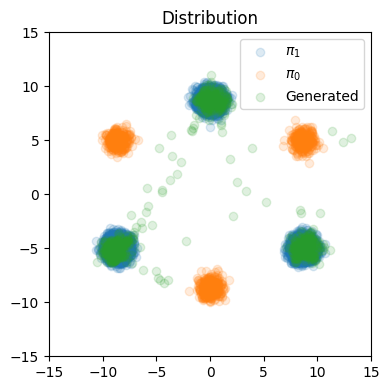

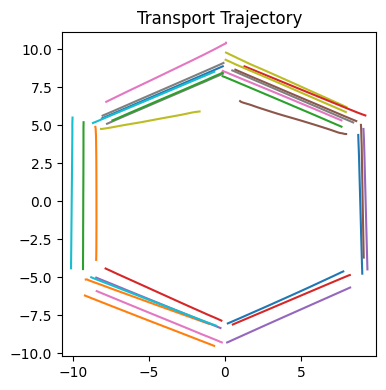

In [67]:
draw_plot(rectified_flow_2, z0=initial_model.sample([1000]), z1=samples_1.detach().clone())

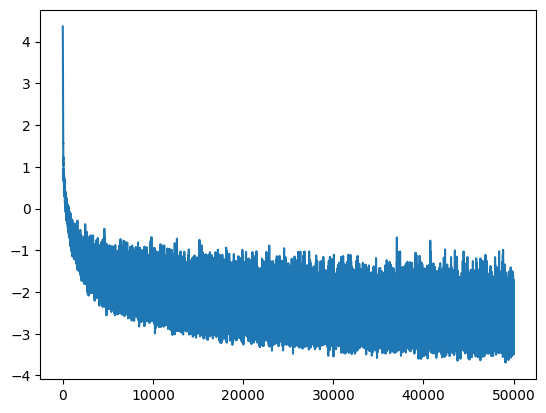

In [68]:
#3-rectified flow
z20 = z10.detach().clone()
traj = rectified_flow_2.sample_ode(z0=z10.detach().clone(), N=100)
z21 = traj[-1].detach().clone()
z_pairs = torch.stack([z10, z11], dim=1)


reflow_iterations = 50000

rectified_flow_3 = RectifiedFlow(model=MLP(input_dim, hidden_num=100), num_steps=100)
rectified_flow_3.net = copy.deepcopy(rectified_flow_2) # same fine-tune logic
optimizer = torch.optim.Adam(rectified_flow_3.model.parameters(), lr=5e-3)

rectified_flow_3, loss_curve = train_rectified_flow(rectified_flow_3, optimizer, z_pairs, batchsize, reflow_iterations)
plt.plot(np.linspace(0, reflow_iterations, reflow_iterations+1), loss_curve[:(reflow_iterations+1)])

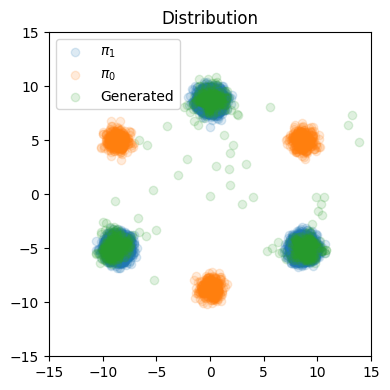

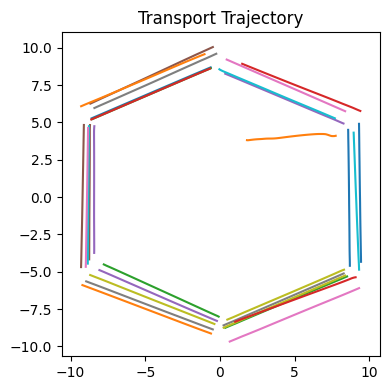

In [69]:
draw_plot(rectified_flow_3, z0=initial_model.sample([1000]), z1=samples_1.detach().clone())

As we can see, the trajectory map is the difference for the 2-,3-rectified flow. There is no more trajectories hoes through the center.  In 2-rectified flow we have 2 deviating trajectories, In 3-rectified flow we have just 1.

#### Part 4

In [ ]:
class RectifiedFlowInverse():
  def __init__(self, model=None, num_steps=1000):
    self.model = model
    self.N = num_steps

  def get_train_tuple(self, z0=None, z1=None):
    t = torch.rand((z1.shape[0], 1))
    z_t =  t * z0 + (1.-t) * z1 # inverse interpolation
    target = z0 - z1

    return z_t, t, target

  @torch.no_grad()
  def sample_ode(self, z0=None, N=None):
    ### NOTE: Use Euler method to sample from the learned flow
    if N is None:
      N = self.N

    dt = 1./N
    traj = [] # to store the trajectory
    z = z0.detach().clone()
    batchsize = z.shape[0]

    traj.append(z.detach().clone())
    for i in range(N):
      t = torch.ones((batchsize,1)) *(1 - i / N) # inverse time
      pred = self.model(z, t)
      z = z.detach().clone() - pred * dt # inverse flow

      traj.append(z.detach().clone())

    return traj

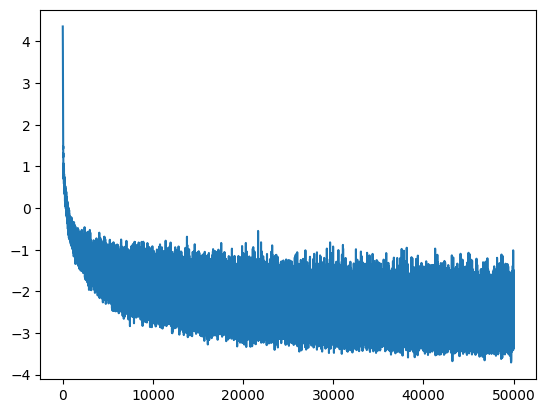

In [74]:
#2-rectified inversed flow
z10 = samples_0.detach().clone()
traj = rectified_flow_1.sample_ode(z0=z10.detach().clone(), N=100)
z11 = traj[-1].detach().clone()
z_pairs = torch.stack([z11, z10], dim=1) #inverse stack


rectified_inverse_flow_2 = RectifiedFlowInverse(model=MLP(input_dim, hidden_num=100), num_steps=100)
optimizer = torch.optim.Adam(rectified_inverse_flow_2.model.parameters(), lr=5e-3)

rectified_inverse_flow_2, loss_curve = train_rectified_flow(rectified_inverse_flow_2, optimizer, z_pairs, batchsize, reflow_iterations)
plt.plot(np.linspace(0, reflow_iterations, reflow_iterations+1), loss_curve[:(reflow_iterations+1)])

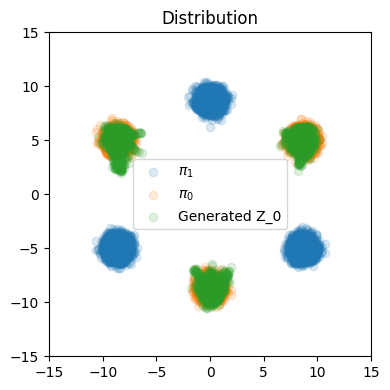

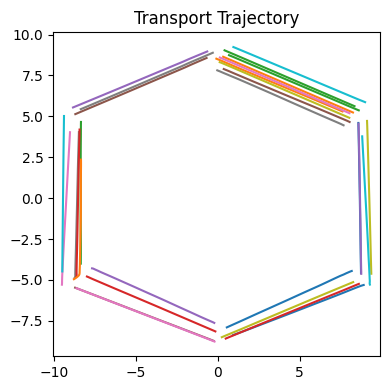

In [75]:
@torch.no_grad()
def draw_plot_inverse(rectified_flow, z0, z1, N=None):
  traj = rectified_flow.sample_ode(z0=z1, N=N)

  plt.figure(figsize=(4,4))
  plt.xlim(-M,M)
  plt.ylim(-M,M)

  plt.scatter(z1[:, 0].cpu().numpy(), z1[:, 1].cpu().numpy(), label=r'$\pi_1$', alpha=0.15)
  plt.scatter(z0[:, 0].cpu().numpy(), z0[:, 1].cpu().numpy(), label=r'$\pi_0$', alpha=0.15)
  plt.scatter(traj[-1][:, 0].cpu().numpy(), traj[-1][:, 1].cpu().numpy(), label='Generated Z_0', alpha=0.15)
  plt.legend()
  plt.title('Distribution')
  plt.tight_layout()

  traj_particles = torch.stack(traj)
  plt.figure(figsize=(4,4))
  plt.xlim(-M,M)
  plt.ylim(-M,M)
  plt.axis('equal')
  for i in range(30):
    plt.plot(traj_particles[:, i, 0], traj_particles[:, i, 1])
  plt.title('Transport Trajectory')
  plt.tight_layout()

draw_plot_inverse(rectified_inverse_flow_2, z0=samples_0.detach().clone(), z1=samples_1.detach().clone(), N=100)

As we can see, now we do not have any deviating trajectories